In [18]:
from pathlib import Path
from microsim import schema as ms
from microsim.util import ortho_plot
import numpy as np
from tqdm import tqdm
import math
from tifffile import imwrite, imread
import argparse

sim = ms.Simulation(
    truth_space=ms.ShapeScaleSpace(shape=(113, 512, 512), scale=(0.02, 0.01, 0.01)),
    output_space={"downscale": 4},
    sample=ms.Sample(labels=[ms.MatsLines(density=1.0, length=8, azimuth=10, max_r=math.sqrt(2))]),
    modality=ms.Confocal(pinhole_au=1.0),
    detector=ms.CameraCCD(qe=0.82, full_well=18000, read_noise=6, bit_depth=12, offset=100),
    settings=ms.Settings(random_seed=None, max_psf_radius_aus=4, np_backend="numpy", device='cpu')    
)

generated_images = []
pinholes = np.linspace(0.5, 5.75,22)

In [21]:
sample = imread("/group/jug/Anirban/Datasets/AllenNeuron/rotated/313861608_0.tif")
sim = sim.model_copy(update=dict(sample=sample))
gt = sim.from_ground_truth(ground_truth=sample, scale=(0.02, 0.01, 0.01))
all_images_noisy = []
all_images_clean = []

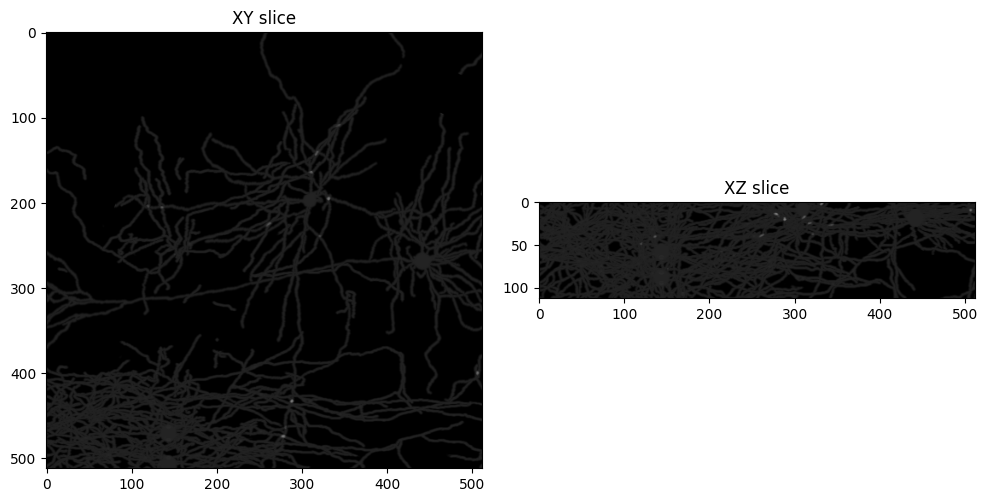

In [28]:
# print(gt.sample.labels[0].distribution.array)
ortho_plot(gt.sample.labels[0].distribution.array, mip=True)

In [31]:
#convert gt to a DataArray
emission_flux = sim.emission_flux(gt)
optical_img = sim.optical_image(emission_flux)

NameError: name 'DataArray' is not defined

In [3]:
pinholes = np.linspace(0.5, 5.75,22)
print(pinholes[::3])

[0.5  1.25 2.   2.75 3.5  4.25 5.   5.75]


In [4]:
#save the generated images
generated_images = np.array(generated_images)
np.save("generated_images.npy", generated_images)

In [5]:
ortho_plot(generated_images[0], mip=False)
generated_images[0].shape

IndexError: index 0 is out of bounds for axis 0 with size 0

In [63]:
#make the values of generated images power normalized
generated_images_16 = np.power(generated_images[0][16], 0.2)
import matplotlib.pyplot as plt
plt.imshow(generated_images_16)


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
generated_images = np.stack(generated_images)
generated_images.shape

### No Normalization

In [ ]:
#plot all generated images 5 in a row
from tifffile import imwrite
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import PowerNorm

gamma: float = 0.5

generated_images = np.stack(generated_images)

_, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
plt.suptitle(f"density: {density}, length: {length}, azimuth: {azimuth}, max_r: {max_r}")
plt.subplots_adjust(top=0.94)
for i in range(generated_images.shape[0]):
    img = generated_images[i][generated_images.shape[1] // 2]
    axs[i//4, i%4].imshow(img, cmap='magma', norm=PowerNorm(gamma))
    title = f"{pinholes[i]:.2f} AU, min_max: {img.min():.2f}, {img.max():.2f}"
    axs[i//4, i%4].set_title(title)
plt.show()

#plot all the histograms of the generated images overlaid on top of each other
_, ax = plt.subplots(figsize=(10, 5))
for i in range(generated_images.shape[0]):
    img = generated_images[i][generated_images.shape[1] // 2]
    ax.plot(np.histogram(img, bins=50)[1][:-1], np.histogram(img, bins=50)[0], label=f"{pinholes[i]:.2f} AU")
ax.legend()
plt.show()

#for all the generated images, extract the data and save the 16th slice as a tiff
saves = []
for i in range(generated_images.shape[0]):
    img = generated_images[i][generated_images.shape[1] // 2]
    generated_images_save = img
    saves.append(generated_images_save)
saves = np.array(saves)
imwrite(f'density_{density}_length_{length}_azimuth_{azimuth}_max_r_{max_r}_noNorm.tif', saves)


### Mean, Standard Deviation Normalization per AU

In [ ]:
#plot all generated images 5 in a row
from tifffile import imwrite
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import PowerNorm

gamma: float = 0.5

generated_images = np.stack(generated_images)

_, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
plt.suptitle(f"density: {density}, length: {length}, azimuth: {azimuth}, max_r: {max_r}")
plt.subplots_adjust(top=0.94)
for i in range(generated_images.shape[0]):
    img = generated_images[i][generated_images.shape[1] // 2]
    img = (img - img.mean()) / img.std()
    axs[i//4, i%4].imshow(img, cmap='magma', norm=PowerNorm(gamma))
    title = f"{pinholes[i]:.2f} AU, min_max: {img.min():.2f}, {img.max():.2f}"
    axs[i//4, i%4].set_title(title)
plt.show()

#plot all the histograms of the generated images overlaid on top of each other
_, ax = plt.subplots(figsize=(10, 5))
for i in range(generated_images.shape[0]):
    img = generated_images[i][generated_images.shape[1] // 2]
    img = (img - img.mean()) / img.std()
    ax.plot(np.histogram(img, bins=50)[1][:-1], np.histogram(img, bins=50)[0], label=f"{pinholes[i]:.2f} AU")
ax.legend()
plt.show()

#for all the generated images, extract the data and save the 16th slice as a tiff
saves = []
for i in range(generated_images.shape[0]):
    img = generated_images[i][generated_images.shape[1] // 2]
    img = (img - img.mean()) / img.std()
    generated_images_save = img
    saves.append(generated_images_save)
saves = np.array(saves)
imwrite(f'density_{density}_length_{length}_azimuth_{azimuth}_max_r_{max_r}_MeanStdNorm.tif', saves)


### Generate outline plot of the intensity profile of the real microscopy image

In [ ]:
from tifffile import imread
import numpy as np
import matplotlib.pyplot as plt
imgs = imread('/home/anirban.ray/Projects/Diffusion_September/microsim/examples/2023-02-17_04-3_orig_stack_corrected.tif')
#for all 23 images, plot the histogram outliner overlaid on each other with a different color
_, ax = plt.subplots(figsize=(10, 5))
for i in range(5):
    img = imgs[i]
    ax.plot(np.histogram(img, bins=10)[1][:-1], np.histogram(img, bins=10)[0], label=f"{pinholes[i]:.2f} Step")
ax.legend()
plt.show()